In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import implicit
from scipy.sparse import coo_matrix
from implicit.evaluation import mean_average_precision_at_k
from tqdm import tqdm


In [2]:
transactions = pd.read_csv('data/transactions_train.csv')
customers = pd.read_csv('data/customers.csv')
articles = pd.read_csv('data/articles.csv')
sample_submission = pd.read_csv('data/sample_submission.csv', dtype={'customer_id': str})

In [3]:
print("transactions columns : ", transactions.columns)
print("articles columns : ", articles.columns)
print("customers columns : ", customers.columns)



transactions columns :  Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id'], dtype='object')
articles columns :  Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')
customers columns :  Index(['customer_id', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code'],
      dtype='object')


In [4]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
#print(transactions.isna().sum())
print(transactions.duplicated().sum())
# Sélectionner toutes les lignes dupliquées
duplicates = transactions[transactions.duplicated(keep=False)]

# Afficher par exemple les 10 premières lignes dupliquées
print(duplicates.head(10))

2974905
        t_dat                                        customer_id  article_id  \
14 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   501820043   
15 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   501820043   
17 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   671505001   
18 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   671505001   
19 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   631848002   
20 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   631848002   
21 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   631848002   
22 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   631848002   
24 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   676827002   
25 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   676827002   

       price  sales_channel_id  
14  0.016932                 2  
15  0.016932                 2  
17  0.033881

In [5]:
missing_customers = customers.isna().mean().sort_values(ascending=False)
missing_customers

Active                    0.661508
FN                        0.652378
fashion_news_frequency    0.011670
age                       0.011561
club_member_status        0.004418
customer_id               0.000000
postal_code               0.000000
dtype: float64

In [6]:
trans_cust = transactions.merge(
    customers[['customer_id', 'Active']],
    on='customer_id',
    how='left'
)
# Tous les utilisateurs avec Active = 1
active_users = trans_cust[trans_cust['Active'] == 1]['customer_id'].unique()
# Tous les utilisateurs avec Active = NaN
nan_users = trans_cust[trans_cust['Active'].isna()]['customer_id'].unique()
# Nombre de transactions par utilisateur
trans_per_user = trans_cust.groupby('customer_id').size()
active_trans_per_user = trans_per_user.loc[active_users]
nan_trans_per_user = trans_per_user.loc[nan_users]
print("Active = 1")
print(active_trans_per_user.describe())

print("\nActive = NaN")
print(nan_trans_per_user.describe())


Active = 1
count    460899.000000
mean         29.021230
std          45.962239
min           1.000000
25%           4.000000
50%          13.000000
75%          35.000000
max        1441.000000
dtype: float64

Active = NaN
count    901382.000000
mean         20.426931
std          34.959920
min           1.000000
25%           3.000000
50%           8.000000
75%          23.000000
max        1895.000000
dtype: float64


| Groupe        | Nombre d’utilisateurs | Moyenne transactions | Médiane | 25% | 75% | Min | Max | Conclusion |
|---------------|---------------------|--------------------|---------|-----|-----|-----|-----|------------|
| Active = 1    | 460 899             | 29,0               | 13      | 4   | 35  | 1   | 1441 | Clients actifs avec un nombre de transactions relativement élevé et distribution large. |
| Active = NaN  | 901 382             | 20,4               | 8       | 3   | 23  | 1   | 1895 | Clients généralement peu actifs ; NaN peut être considéré comme Active=0 pour l’analyse. |


In [7]:
# Convertir t_dat en datetime si ce n'est pas déjà fait
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Dernière transaction par utilisateur
last_trans_per_user = trans_cust.groupby('customer_id')['t_dat'].max()
# Active = 1
active_last_trans = last_trans_per_user.loc[active_users]

# Active = NaN
nan_last_trans = last_trans_per_user.loc[nan_users]
print("Active = 1")
print(active_last_trans.describe())

print("\nActive = NaN")
print(nan_last_trans.describe())

Active = 1
count                           460899
mean     2020-03-06 00:24:30.996465152
min                2018-09-20 00:00:00
25%                2019-11-08 00:00:00
50%                2020-06-16 00:00:00
75%                2020-08-19 00:00:00
max                2020-09-22 00:00:00
Name: t_dat, dtype: object

Active = NaN
count                           901382
mean     2020-01-12 20:53:38.865254144
min                2018-09-20 00:00:00
25%                2019-07-19 00:00:00
50%                2020-03-31 00:00:00
75%                2020-07-26 00:00:00
max                2020-09-22 00:00:00
Name: t_dat, dtype: object


| Groupe        | Nb clients | Nb transactions (moyenne) | Nb transactions (médiane) | Dernière transaction moyenne | Médiane date dernière transaction | Min date | Max date |
|---------------|------------|---------------------------|---------------------------|------------------------------|---------------------------------|----------|----------|
| Active = 1    | 460 899    | 29,0                      | 13                        | 2020-03-06                   | 2020-06-16                      | 2018-09-20 | 2020-09-22 |
| Active = NaN  | 901 382    | 20,4                      | 8                         | 2020-01-12                   | 2020-03-31                      | 2018-09-20 | 2020-09-22 |


In [8]:
# Quartiles
trans_q1 = trans_per_user.quantile(0.25)
date_q1 = last_trans_per_user.quantile(0.25)

print(f"Seuil transactions Q1: {trans_q1}")
print(f"Seuil date dernière transaction Q1: {date_q1}")
# Mask pour NaN
mask_nan = customers['Active'].isna()

# Récupérer transactions et dernière date pour ces clients, alignés avec mask_nan
num_trans_nan = trans_per_user.reindex(customers.loc[mask_nan, 'customer_id']).fillna(0).values
last_trans_nan = last_trans_per_user.reindex(customers.loc[mask_nan, 'customer_id']).fillna(pd.Timestamp.min).values

# Remplacer Active NaN
customers.loc[mask_nan, 'Active'] = ((num_trans_nan > trans_q1) & (last_trans_nan >= date_q1)).astype(int)

# Vérification
customers['Active'].value_counts(dropna=False)

Seuil transactions Q1: 3.0
Seuil date dernière transaction Q1: 2019-08-21 00:00:00


Active
1.0    977698
0.0    394282
Name: count, dtype: int64

In [9]:
#FN
customers['FN'] = customers['FN'].fillna(0).astype(int)


In [10]:
#age
customers['age'].unique()
customers['age'] = customers['age'].fillna(customers['age'].median())


In [11]:
#fashion news
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')
customers['fashion_news_frequency'].unique()


array(['NONE', 'Regularly', 'Monthly'], dtype=object)

In [12]:
#club_member_status
customers['club_member_status'].unique()
print(customers['club_member_status'].value_counts())
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')


club_member_status
ACTIVE        1272491
PRE-CREATE      92960
LEFT CLUB         467
Name: count, dtype: int64


In [13]:
articles.drop(columns='detail_desc', inplace=True)
missing_articles = articles.isna().mean().sort_values(ascending=False)
missing_articles


article_id                      0.0
product_code                    0.0
garment_group_no                0.0
section_name                    0.0
section_no                      0.0
index_group_name                0.0
index_group_no                  0.0
index_name                      0.0
index_code                      0.0
department_name                 0.0
department_no                   0.0
perceived_colour_master_name    0.0
perceived_colour_master_id      0.0
perceived_colour_value_name     0.0
perceived_colour_value_id       0.0
colour_group_name               0.0
colour_group_code               0.0
graphical_appearance_name       0.0
graphical_appearance_no         0.0
product_group_name              0.0
product_type_name               0.0
product_type_no                 0.0
prod_name                       0.0
garment_group_name              0.0
dtype: float64

In [14]:
# Date maximale dans ton dataset
max_date = transactions['t_dat'].max()

# Fenêtre de test : dernière semaine
test_start = max_date - pd.Timedelta(days=6)  # dernière semaine
test_end = max_date

# Fenêtre d'entraînement : les 5 semaines avant la dernière semaine
train_start = test_start - pd.Timedelta(weeks=5)
transactions_train = transactions[(transactions['t_dat'] >= train_start) & (transactions['t_dat'] < test_start)]
transactions_test  = transactions[(transactions['t_dat'] >= test_start) & (transactions['t_dat'] <= test_end)]

In [15]:
stats = pd.DataFrame({
    "Train": [
        len(transactions_train),                          # transactions
        transactions_train['article_id'].nunique(),      # articles
        transactions_train['customer_id'].nunique()      # customers
    ],
    "Test": [
        len(transactions_test),
        transactions_test['article_id'].nunique(),
        transactions_test['customer_id'].nunique()
    ]
}, index=["Transactions", "Articles", "Customers"])
stats

,Train,Test
Transactions,1324934,240311
Articles,30979,17986
Customers,274594,68984


In [16]:
# ==============================
# 1. Préparation des données
# ==============================

ALL_USERS = transactions_train['customer_id'].unique()
ALL_ITEMS = transactions_train['article_id'].unique()


user_ids = dict(enumerate(ALL_USERS))
item_ids = dict(enumerate(ALL_ITEMS))

user_map = {u: uidx for uidx, u in user_ids.items()}
item_map = {i: iidx for iidx, i in item_ids.items()}

transactions_train['user_id'] = transactions_train['customer_id'].map(user_map)
transactions_train['item_id'] = transactions_train['article_id'].map(item_map)

transactions_train = transactions_train.dropna(subset=['user_id', 'item_id'])


C:\Users\ajarr\AppData\Local\Temp\ipykernel_15772\4262387640.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_train['user_id'] = transactions_train['customer_id'].map(user_map)
C:\Users\ajarr\AppData\Local\Temp\ipykernel_15772\4262387640.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_train['item_id'] = transactions_train['article_id'].map(item_map)


Nb users : 274594
Nb items : 30979
Nb transactions : 1324934


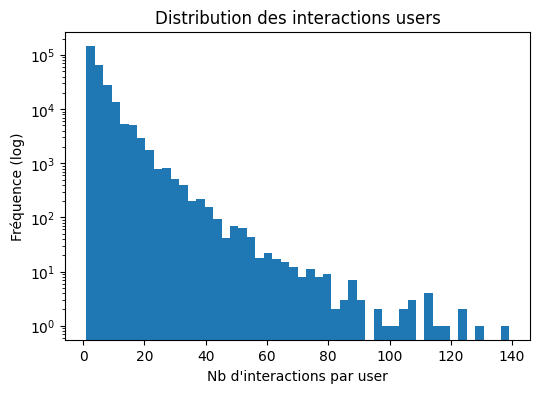

In [17]:
print("Nb users :", len(ALL_USERS))
print("Nb items :", len(ALL_ITEMS))
print("Nb transactions :", len(transactions_train))
transactions_train[['customer_id', 'user_id', 'article_id', 'item_id']].head()
import matplotlib.pyplot as plt

user_interactions_train = transactions_train.groupby('user_id').size()

plt.figure(figsize=(6,4))
plt.hist(user_interactions_train, bins=50)
plt.yscale('log')
plt.xlabel("Nb d'interactions par user")
plt.ylabel("Fréquence (log)")
plt.title("Distribution des interactions users")
plt.show()


=== Métriques Users ===
Moyenne d'interactions par user: 4.83
Médiane d'interactions par user: 3
Ratio total: 4.83

Users avec ≤5 interactions: 198343 (72.23%)
Users avec ≤10 interactions: 248097 (90.35%)
Users avec >50 interactions: 260 (0.09%)

=== Métriques Items ===
Moyenne d'interactions par item: 42.77
Médiane d'interactions par item: 7


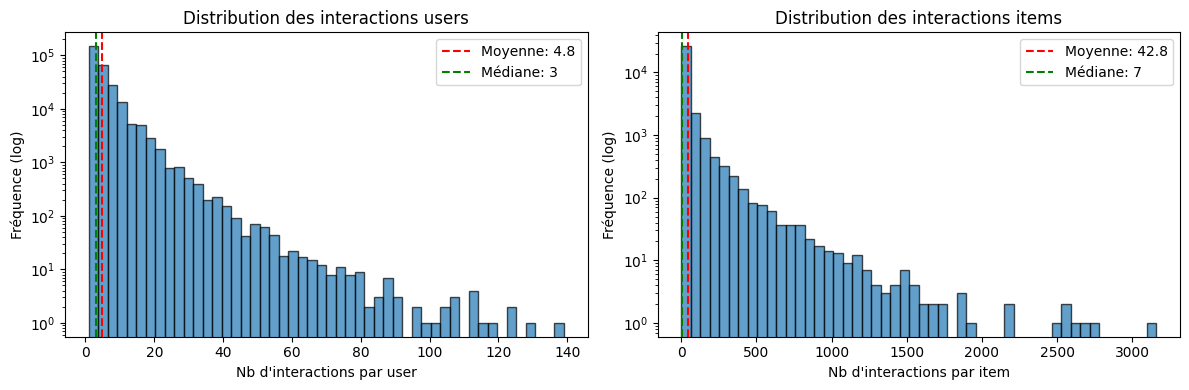


=== Statistiques détaillées Users ===
count    274594.000000
mean          4.825065
std           5.273208
min           1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         139.000000
dtype: float64

=== Statistiques détaillées Items ===
count    30979.000000
mean        42.768779
std        119.602557
min          1.000000
25%          2.000000
50%          7.000000
75%         31.000000
max       3159.000000
dtype: float64


In [18]:
import numpy as np

# Interactions par user
user_interactions = transactions_train.groupby('user_id').size()

# Métriques de base
mean_interactions_user = user_interactions.mean()
median_interactions_user = user_interactions.median()
ratio_interactions_user = len(transactions_train) / len(ALL_USERS)

print("=== Métriques Users ===")
print(f"Moyenne d'interactions par user: {mean_interactions_user:.2f}")
print(f"Médiane d'interactions par user: {median_interactions_user:.0f}")
print(f"Ratio total: {ratio_interactions_user:.2f}")

# Distribution par seuils
users_le_5 = (user_interactions <= 5).sum()
pct_users_le_5 = (users_le_5 / len(user_interactions)) * 100

users_le_10 = (user_interactions <= 10).sum()
pct_users_le_10 = (users_le_10 / len(user_interactions)) * 100

users_gt_50 = (user_interactions > 50).sum()
pct_users_gt_50 = (users_gt_50 / len(user_interactions)) * 100

print(f"\nUsers avec ≤5 interactions: {users_le_5} ({pct_users_le_5:.2f}%)")
print(f"Users avec ≤10 interactions: {users_le_10} ({pct_users_le_10:.2f}%)")
print(f"Users avec >50 interactions: {users_gt_50} ({pct_users_gt_50:.2f}%)")

# Interactions par item
item_interactions = transactions_train.groupby('item_id').size()

mean_interactions_item = item_interactions.mean()
median_interactions_item = item_interactions.median()

print("\n=== Métriques Items ===")
print(f"Moyenne d'interactions par item: {mean_interactions_item:.2f}")
print(f"Médiane d'interactions par item: {median_interactions_item:.0f}")

# Visualisation distribution items
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(user_interactions, bins=50, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.xlabel("Nb d'interactions par user")
plt.ylabel("Fréquence (log)")
plt.title("Distribution des interactions users")
plt.axvline(mean_interactions_user, color='red', linestyle='--', label=f'Moyenne: {mean_interactions_user:.1f}')
plt.axvline(median_interactions_user, color='green', linestyle='--', label=f'Médiane: {median_interactions_user:.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(item_interactions, bins=50, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.xlabel("Nb d'interactions par item")
plt.ylabel("Fréquence (log)")
plt.title("Distribution des interactions items")
plt.axvline(mean_interactions_item, color='red', linestyle='--', label=f'Moyenne: {mean_interactions_item:.1f}')
plt.axvline(median_interactions_item, color='green', linestyle='--', label=f'Médiane: {median_interactions_item:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

# Statistiques descriptives complètes
print("\n=== Statistiques détaillées Users ===")
print(user_interactions.describe())

print("\n=== Statistiques détaillées Items ===")
print(item_interactions.describe())


### Conclusion:

Utilisateurs : médiane 3 interactions, 72 % ≤5, 90 % ≤10 → majorité peu actifs, personnalisation limitée.

Articles : médiane 7 interactions, mean 42.8, max 3159 → longue traîne avec quelques produits très populaires.

Modèle ALS : efficace pour les utilisateurs actifs, mais faible signal pour la majorité.

Recommandations : approche hybride (ALS + popularité) nécessaire pour couvrir tous les profils.

In [19]:
# ==============================
# 2. Création matrice pondérée
# ==============================

def to_user_item_coo_weighted(df, decay_days=30):
    max_date = df['t_dat'].max()
    df['days_ago'] = (max_date - df['t_dat']).dt.days
    df['weight'] = np.exp(-df['days_ago'] / decay_days).astype(np.float32)
    coo = coo_matrix((df['weight'], (df['user_id'], df['item_id'])),
                     shape=(len(ALL_USERS), len(ALL_ITEMS)))
    return coo

coo_full = to_user_item_coo_weighted(transactions_train)
csr_full = coo_full.tocsr()

In [20]:
nnz = coo_full.nnz
total = coo_full.shape[0] * coo_full.shape[1]
sparsity = 1 - nnz / total

print(f"Shape de la matrice : {coo_full.shape}")
print(f"Nombre de valeurs non nulles : {nnz}")
print(f"Sparsité : {sparsity:.6f} ({sparsity*100:.4f} %)")


Shape de la matrice : (274594, 30979)
Nombre de valeurs non nulles : 1324934
Sparsité : 0.999844 (99.9844 %)


In [21]:
# ==============================
# 3. Entraînement ALS
# ==============================
als_model = implicit.als.AlternatingLeastSquares(
    factors=200,
    iterations=7,
    regularization=0.01,
    random_state=42,
    calculate_training_loss=True
)
als_model.fit(csr_full)

print("ALS entraîné ! user_factors shape :", als_model.user_factors.shape)

C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/7 [00:00<?, ?it/s]

ALS entraîné ! user_factors shape : (274594, 200)


In [22]:
transactions_test['user_id'] = transactions_test['customer_id'].map(user_map)
transactions_test['item_id'] = transactions_test['article_id'].map(item_map)

transactions_test = transactions_test.dropna(subset=['user_id', 'item_id'])
transactions_test['user_id'] = transactions_test['user_id'].astype(int)
transactions_test['item_id'] = transactions_test['item_id'].astype(int)

gt_test = (
    transactions_test
    .groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)
# garder uniquement les users vus au train
train_users = set(transactions_train["user_id"].unique())
gt_test = {u: items for u, items in gt_test.items() if u in train_users}

import numpy as np
from tqdm import tqdm

def map_at_12(model, user_item_csr, ground_truth):
    ap_scores = []

    for user_id, true_items in tqdm(ground_truth.items()):
        if not true_items:
            continue

        recs, _ = model.recommend(
            userid=user_id,
            user_items=user_item_csr[user_id],
            N=12,
            filter_already_liked_items=True
        )

        score = 0.0
        hits = 0

        for rank, item in enumerate(recs):
            if item in true_items:
                hits += 1
                score += hits / (rank + 1)

        ap = score / min(len(true_items), 12) if hits > 0 else 0.0
        ap_scores.append(ap)

    return float(np.mean(ap_scores))
map12 = map_at_12(
    model=als_model,
    user_item_csr=csr_full,
    ground_truth=gt_test
)

print(f"MAP@12 : {map12:.5f}")



C:\Users\ajarr\AppData\Local\Temp\ipykernel_15772\986795140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_test['user_id'] = transactions_test['customer_id'].map(user_map)
C:\Users\ajarr\AppData\Local\Temp\ipykernel_15772\986795140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_test['item_id'] = transactions_test['article_id'].map(item_map)
100%|██████████| 33917/33917 [01:53<00:00, 298.89it/s]

MAP@12 : 0.01003


### ALS+ features:


In [23]:
# ==============================
# Fallback popular items (100 items)
# ==============================
recent_popular = transactions_train.groupby("article_id")["t_dat"].count().sort_values(ascending=False).head(100)
popular_items = recent_popular.index.tolist()
# ==============================
#  Pré-calcul historique achats
# ==============================
user_history_train = transactions_train.groupby("customer_id")["article_id"].apply(set).to_dict()
user_history_test  = transactions_test.groupby("customer_id")["article_id"].apply(set).to_dict()


In [24]:
import pandas as pd
import numpy as np
from datetime import timedelta
from collections import defaultdict
from tqdm.auto import tqdm
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_classif
from scipy.sparse import coo_matrix
import implicit
import gc

# =============================================
#  ÉTAPE 1 : PRÉPARATION ALS (votre code)
# =============================================
print("=" * 70)
print(" PIPELINE COMPLET : ALS + FEATURE ENGINEERING + LIGHTGBM")
print("=" * 70)


# 1.3 Pré-calcul cache ALS (TOP 100 par user)
print("\n Création cache ALS (top 100 par user)...")
als_cache = {}

for user_id in tqdm(range(len(ALL_USERS)), desc="Cache ALS"):
    recs, scores = als_model.recommend(
        userid=user_id,
        user_items=csr_full[user_id],
        N=30,
        filter_already_liked_items=False
    )
    als_cache[user_id] = dict(zip(recs, scores))

print(f" Cache créé pour {len(als_cache):,} users")

# 1.4 Popular items (TOP 100)
print("\n Identification popular items...")
recent_popular = transactions_train.groupby("article_id")["t_dat"].count().sort_values(ascending=False).head(20)
popular_items = recent_popular.index.tolist()
popular_items_idx = [item_map[aid] for aid in popular_items if aid in item_map]
print(f" {len(popular_items_idx)} popular items")

# 1.5 Historique achats
print("\n Création historiques achats...")
user_history_train = transactions_train.groupby("customer_id")["article_id"].apply(set).to_dict()
user_history_test = transactions_test.groupby("customer_id")["article_id"].apply(set).to_dict()
print(f" Train: {len(user_history_train):,} users, Test: {len(user_history_test):,} users")




 PIPELINE COMPLET : ALS + FEATURE ENGINEERING + LIGHTGBM

 Création cache ALS (top 100 par user)...


Cache ALS:   0%|          | 0/274594 [00:00<?, ?it/s]

 Cache créé pour 274,594 users

 Identification popular items...
 20 popular items

 Création historiques achats...
 Train: 274,594 users, Test: 33,917 users


In [25]:
# =============================================
#  ÉTAPE 2 : FEATURE ENGINEERING
# =============================================
print("\n" + "=" * 70)
print(" FEATURE ENGINEERING")
print("=" * 70)

def create_user_features(transactions_train, customers):
    """Features comportementales utilisateur"""
    
    user_stats = transactions_train.groupby('customer_id').agg({
        'article_id': 'count',
        'price': ['sum', 'mean', 'std'],
        't_dat': ['min', 'max']
    })
    
    user_stats.columns = ['n_purchases', 'total_spent', 'avg_price', 'std_price',
                          'first_purchase', 'last_purchase']
    
    # Récence et fréquence
    max_date = transactions_train['t_dat'].max()
    user_stats['recency_days'] = (max_date - user_stats['last_purchase']).dt.days
    user_stats['lifetime_days'] = (user_stats['last_purchase'] - user_stats['first_purchase']).dt.days + 1
    user_stats['purchase_frequency'] = user_stats['n_purchases'] / user_stats['lifetime_days']
    
    # Diversité
    user_diversity = transactions_train.groupby('customer_id')['article_id'].nunique()
    user_stats['n_unique_items'] = user_diversity
    user_stats['diversity_rate'] = user_diversity / user_stats['n_purchases']
    
    # Démographie
    user_stats = user_stats.merge(customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency']], 
                                  left_index=True, right_on='customer_id', how='left')
    
    user_stats['age_group'] = pd.cut(user_stats['age'], bins=[0, 25, 35, 45, 55, 100], labels=[0, 1, 2, 3, 4]).astype(float)
    
    # Encoder categorical
    user_stats['club_member'] = (user_stats['club_member_status'] == 'ACTIVE').astype(int)
    user_stats['news_regular'] = (user_stats['fashion_news_frequency'] == 'Regularly').astype(int)
    
    return user_stats.set_index('customer_id')


def create_item_features(transactions_train, articles):
    """Features articles (popularité + métadata)"""
    
    item_stats = transactions_train.groupby('article_id').agg({
        'customer_id': ['count', 'nunique'],
        'price': ['mean', 'std']
    })
    item_stats.columns = ['n_sales', 'n_unique_users', 'avg_price', 'std_price']
    
    # Popularité récente
    max_date = transactions_train['t_dat'].max()
    for weeks in [1, 2, 4]:
        recent_date = max_date - timedelta(weeks=weeks)
        recent = transactions_train[transactions_train['t_dat'] > recent_date]
        recent_pop = recent.groupby('article_id').size()
        item_stats[f'sales_last_{weeks}w'] = recent_pop
        item_stats[f'sales_last_{weeks}w'] = item_stats[f'sales_last_{weeks}w'].fillna(0)
    
    # Tendance
    item_stats['trend_1w'] = item_stats['sales_last_1w'] / (item_stats['n_sales'] + 1)
    item_stats['trend_4w'] = item_stats['sales_last_4w'] / (item_stats['n_sales'] + 1)
    
    # Taux réachat
    item_stats['repurchase_rate'] = item_stats['n_sales'] / item_stats['n_unique_users']
    
    # Métadata
    item_stats = item_stats.merge(
        articles[['article_id', 'product_type_no', 'product_group_name', 'colour_group_code', 'index_group_no']], 
        left_index=True, right_on='article_id', how='left'
    )
    
    return item_stats.set_index('article_id')


def create_interaction_features(transactions_train, articles):
    """Features interaction user-item"""
    
    # Historique UI
    ui_hist = transactions_train.groupby(['customer_id', 'article_id']).agg({
        't_dat': ['count', 'max'],
        'price': 'mean'
    })
    ui_hist.columns = ['n_purchases_ui', 'last_purchase_ui', 'avg_price_ui']
    ui_hist.reset_index(inplace=True)
    
    max_date = transactions_train['t_dat'].max()
    ui_hist['recency_ui_days'] = (max_date - ui_hist['last_purchase_ui']).dt.days
    
    # Affinité catégorie
    cat_aff = transactions_train.merge(
        articles[['article_id', 'product_type_no']], on='article_id'
    ).groupby(['customer_id', 'product_type_no']).size().reset_index(name='category_purchases')
    
    # Affinité couleur
    color_aff = transactions_train.merge(
        articles[['article_id', 'colour_group_code']], on='article_id'
    ).groupby(['customer_id', 'colour_group_code']).size().reset_index(name='color_purchases')
    
    return {
        'ui_hist': ui_hist,
        'cat_aff': cat_aff,
        'color_aff': color_aff
    }


print("\n Création features...")
user_features = create_user_features(transactions_train, customers)
item_features = create_item_features(transactions_train, articles)
interaction_features = create_interaction_features(transactions_train, articles)

print(f" User features: {user_features.shape}")
print(f" Item features: {item_features.shape}")


# =============================================
#  ÉTAPE 3 : CONSTRUCTION DATASET
# =============================================
print("\n" + "=" * 70)
print(" CONSTRUCTION DATASET")
print("=" * 70)

def build_dataset_fast(users, user_features, item_features, interaction_features,
                       user_history_train, user_history_test, 
                       als_cache, popular_items_idx, item_map, ALL_ITEMS):
    """Construction dataset avec TOUTES les features"""
    
    rows = []
    
    # Pré-calculer lookups
    ui_hist_dict = interaction_features['ui_hist'].set_index(['customer_id', 'article_id']).to_dict('index')
    cat_aff_dict = interaction_features['cat_aff'].set_index(['customer_id', 'product_type_no'])['category_purchases'].to_dict()
    color_aff_dict = interaction_features['color_aff'].set_index(['customer_id', 'colour_group_code'])['color_purchases'].to_dict()
    
    for user_id in tqdm(users, desc="Feature engineering"):
        # User features
        if user_id not in user_features.index:
            continue
        u_feat = user_features.loc[user_id]
        
        # Candidats
        candidates = defaultdict(lambda: {"als_score": 0.0, "popular": 0, "repurchase": 0})
        
        # ALS (cache)
        user_idx = user_map.get(user_id)
        if user_idx is not None:
            for item_idx, score in als_cache.get(user_idx, {}).items():
                candidates[item_idx]["als_score"] = score
        
        # Popular
        for idx in popular_items_idx:
            candidates[idx]["popular"] = 1
        
        # Repurchase
        user_hist = user_history_train.get(user_id, set())
        for aid in list(user_hist)[:10]:
            idx = item_map.get(aid)
            if idx is not None:
                candidates[idx]["repurchase"] = 1
        
        bought_train = user_history_train.get(user_id, set())
        bought_test = user_history_test.get(user_id, set())
        
        for item_idx, info in candidates.items():
            article_id = ALL_ITEMS[item_idx]
            
            if article_id not in item_features.index:
                continue
            i_feat = item_features.loc[article_id]
            
            # Interaction
            ui_key = (user_id, article_id)
            ui_data = ui_hist_dict.get(ui_key, {})
            
            cat_key = (user_id, i_feat['product_type_no'])
            cat_affinity = cat_aff_dict.get(cat_key, 0)
            
            color_key = (user_id, i_feat['colour_group_code'])
            color_affinity = color_aff_dict.get(color_key, 0)
            
            # Prix relatif
            price_diff = i_feat['avg_price'] - u_feat['avg_price']
            price_ratio = i_feat['avg_price'] / (u_feat['avg_price'] + 1e-6)
            
            row = {
                'user_id': user_id,
                'item_id': article_id,
                'label': int(article_id in bought_test),
                
                # Base (4)
                'als_score': float(info['als_score']),
                'popular': int(info['popular']),
                'repurchase': int(info['repurchase']),
                'bought_before': int(article_id in bought_train),
                
                # User (8)
                'user_recency': u_feat['recency_days'],
                'user_frequency': u_feat['purchase_frequency'],
                'user_n_purchases': u_feat['n_purchases'],
                'user_diversity': u_feat['diversity_rate'],
                'user_avg_price': u_feat['avg_price'],
                'user_age_group': u_feat['age_group'],
                'user_club_member': u_feat['club_member'],
                'user_news_regular': u_feat['news_regular'],
                
                # Item (9)
                'item_popularity': i_feat['n_sales'],
                'item_trend_1w': i_feat['trend_1w'],
                'item_trend_4w': i_feat['trend_4w'],
                'item_repurchase_rate': i_feat['repurchase_rate'],
                'item_avg_price': i_feat['avg_price'],
                'item_sales_1w': i_feat['sales_last_1w'],
                'item_sales_2w': i_feat['sales_last_2w'],
                'item_sales_4w': i_feat['sales_last_4w'],
                'item_product_type': i_feat['product_type_no'],
                
                # Interaction (6)
                'n_purchases_ui': ui_data.get('n_purchases_ui', 0),
                'recency_ui': ui_data.get('recency_ui_days', 999),
                'category_affinity': cat_affinity,
                'color_affinity': color_affinity,
                'price_diff': price_diff,
                'price_ratio': price_ratio,
            }
            
            rows.append(row)
    
    return pd.DataFrame(rows)
 #Limiter à 10k pour éviter MemoryError
recent_users = list(user_history_train.keys())
SAMPLE_SIZE = min(10000, len(recent_users))
recent_users_sample = np.random.choice(recent_users, size=SAMPLE_SIZE, replace=False)

X_df = build_dataset_fast(
    users=recent_users_sample,
    user_features=user_features,
    item_features=item_features,
    interaction_features=interaction_features,
    user_history_train=user_history_train,
    user_history_test=user_history_test,
    als_cache=als_cache,
    popular_items_idx=popular_items_idx,
    item_map=item_map,
    ALL_ITEMS=ALL_ITEMS
)

print(f"\n Dataset créé: {X_df.shape}")

# Préparation
y = X_df['label'].values
X = X_df.drop(columns=['user_id', 'item_id', 'label'])
group = X_df.groupby('user_id').size().values

print(f" X: {X.shape}, y: {y.shape}, groups: {len(group)}")
print(f"   Positifs: {y.sum():,} ({100*y.mean():.2f}%)")


# =============================================
#  ÉTAPE 4 : SÉLECTION FEATURES
# =============================================
print("\n" + "=" * 70)
print(" SÉLECTION INTELLIGENTE DES FEATURES")
print("=" * 70)

def select_best_features(X, y, threshold=0.001):
    """Garde features avec MI > seuil"""
    
    print("\n Calcul Mutual Information...")
    mi_scores = mutual_info_classif(X, y, random_state=42, n_jobs=-1)
    
    mi_df = pd.DataFrame({
        'feature': X.columns,
        'mi_score': mi_scores
    }).sort_values('mi_score', ascending=False)
    
    print("\n Top 15 features (MI) :")
    print(mi_df.head(15).to_string(index=False))
    
    selected = mi_df[mi_df['mi_score'] > threshold]['feature'].tolist()
    
    print(f"\n Features retenues : {len(selected)}/{len(X.columns)} (seuil MI={threshold})")
    
    return selected, mi_df

selected_features, mi_df = select_best_features(X, y, threshold=0.001)
X_selected = X[selected_features]


 FEATURE ENGINEERING

 Création features...
 User features: (274594, 17)
 Item features: (30979, 14)

 CONSTRUCTION DATASET


Feature engineering:   0%|          | 0/10000 [00:00<?, ?it/s]


 Dataset créé: (522116, 30)
 X: (522116, 27), y: (522116,), groups: 10000
   Positifs: 385 (0.07%)

 SÉLECTION INTELLIGENTE DES FEATURES

 Calcul Mutual Information...

 Top 15 features (MI) :
          feature  mi_score
 user_club_member  0.090821
       recency_ui  0.084464
user_news_regular  0.067702
   user_diversity  0.061776
          popular  0.050317
   user_age_group  0.022122
item_product_type  0.015104
 user_n_purchases  0.006950
   user_frequency  0.006727
   color_affinity  0.006698
category_affinity  0.004233
     user_recency  0.003427
    bought_before  0.002263
       repurchase  0.002250
   n_purchases_ui  0.002092

 Features retenues : 22/27 (seuil MI=0.001)


In [26]:
# =============================================
#  ÉTAPE 5 : LIGHTGBM RANKER OPTIMISÉ
# =============================================
print("\n" + "=" * 70)
print(" ENTRAÎNEMENT LIGHTGBM - TOUS USERS + FEATURES SÉLECTIONNÉES")
print("=" * 70)

# =============================================
#  VÉRIFICATION FEATURES SÉLECTIONNÉES
# =============================================
print("\n Vérification features sélectionnées...")

if 'selected_features' not in locals():
    raise ValueError(" ERREUR: 'selected_features' non trouvé! Exécutez d'abord le code 1 (feature selection)")

print(f" Features sélectionnées: {len(selected_features)}")
print(f"   Top 10: {selected_features[:10]}")

# =============================================
#  CONSTRUCTION DATASET OPTIMISÉE
# =============================================
print("\n Construction dataset OPTIMISÉE (features sélectionnées uniquement)...")

def build_dataset_optimized(users, user_features, item_features, interaction_features,
                           user_history_train, user_history_test, 
                           als_cache, popular_items_idx, item_map, ALL_ITEMS,
                           selected_features):
    """
    Construction dataset en calculant UNIQUEMENT les features sélectionnées.
    Économise mémoire et temps de calcul.
    """
    
    rows = []
    
    # Identifier quelles features sont nécessaires
    need_ui_hist = any('ui' in f or 'recency_ui' in f or 'n_purchases_ui' in f for f in selected_features)
    need_cat_aff = 'category_affinity' in selected_features
    need_color_aff = 'color_affinity' in selected_features
    need_price_features = any('price' in f for f in selected_features)
    
    # Pré-calculer lookups SEULEMENT si nécessaires
    ui_hist_dict = {}
    cat_aff_dict = {}
    color_aff_dict = {}
    
    if need_ui_hist:
        ui_hist_dict = interaction_features['ui_hist'].set_index(['customer_id', 'article_id']).to_dict('index')
    if need_cat_aff:
        cat_aff_dict = interaction_features['cat_aff'].set_index(['customer_id', 'product_type_no'])['category_purchases'].to_dict()
    if need_color_aff:
        color_aff_dict = interaction_features['color_aff'].set_index(['customer_id', 'colour_group_code'])['color_purchases'].to_dict()
    
    for user_id in tqdm(users, desc="Feature engineering optimisée"):
        # User features
        if user_id not in user_features.index:
            continue
        u_feat = user_features.loc[user_id]
        
        # Candidats
        candidates = defaultdict(lambda: {"als_score": 0.0, "popular": 0, "repurchase": 0})
        
        # ALS (cache)
        user_idx = user_map.get(user_id)
        if user_idx is not None:
            for item_idx, score in als_cache.get(user_idx, {}).items():
                candidates[item_idx]["als_score"] = score
        
        # Popular
        for idx in popular_items_idx:
            candidates[idx]["popular"] = 1
        
        # Repurchase
        user_hist = user_history_train.get(user_id, set())
        for aid in list(user_hist)[:10]:
            idx = item_map.get(aid)
            if idx is not None:
                candidates[idx]["repurchase"] = 1
        
        bought_train = user_history_train.get(user_id, set())
        bought_test = user_history_test.get(user_id, set())
        
        for item_idx, info in candidates.items():
            article_id = ALL_ITEMS[item_idx]
            
            if article_id not in item_features.index:
                continue
            i_feat = item_features.loc[article_id]
            
            # Construire UNIQUEMENT les features sélectionnées
            row = {
                'user_id': user_id,
                'item_id': article_id,
                'label': int(article_id in bought_test),
            }
            
            # Base features (toujours calculées car peu coûteuses)
            if 'als_score' in selected_features:
                row['als_score'] = float(info['als_score'])
            if 'popular' in selected_features:
                row['popular'] = int(info['popular'])
            if 'repurchase' in selected_features:
                row['repurchase'] = int(info['repurchase'])
            if 'bought_before' in selected_features:
                row['bought_before'] = int(article_id in bought_train)
            
            # User features
            if 'user_recency' in selected_features:
                row['user_recency'] = u_feat['recency_days']
            if 'user_frequency' in selected_features:
                row['user_frequency'] = u_feat['purchase_frequency']
            if 'user_n_purchases' in selected_features:
                row['user_n_purchases'] = u_feat['n_purchases']
            if 'user_diversity' in selected_features:
                row['user_diversity'] = u_feat['diversity_rate']
            if 'user_avg_price' in selected_features:
                row['user_avg_price'] = u_feat['avg_price']
            if 'user_age_group' in selected_features:
                row['user_age_group'] = u_feat['age_group']
            if 'user_club_member' in selected_features:
                row['user_club_member'] = u_feat['club_member']
            if 'user_news_regular' in selected_features:
                row['user_news_regular'] = u_feat['news_regular']
            
            # Item features
            if 'item_popularity' in selected_features:
                row['item_popularity'] = i_feat['n_sales']
            if 'item_trend_1w' in selected_features:
                row['item_trend_1w'] = i_feat['trend_1w']
            if 'item_trend_4w' in selected_features:
                row['item_trend_4w'] = i_feat['trend_4w']
            if 'item_repurchase_rate' in selected_features:
                row['item_repurchase_rate'] = i_feat['repurchase_rate']
            if 'item_avg_price' in selected_features:
                row['item_avg_price'] = i_feat['avg_price']
            if 'item_sales_1w' in selected_features:
                row['item_sales_1w'] = i_feat['sales_last_1w']
            if 'item_sales_2w' in selected_features:
                row['item_sales_2w'] = i_feat['sales_last_2w']
            if 'item_sales_4w' in selected_features:
                row['item_sales_4w'] = i_feat['sales_last_4w']
            if 'item_product_type' in selected_features:
                row['item_product_type'] = i_feat['product_type_no']
            
            # Interaction features (calculées SEULEMENT si nécessaires)
            if need_ui_hist:
                ui_key = (user_id, article_id)
                ui_data = ui_hist_dict.get(ui_key, {})
                if 'n_purchases_ui' in selected_features:
                    row['n_purchases_ui'] = ui_data.get('n_purchases_ui', 0)
                if 'recency_ui' in selected_features:
                    row['recency_ui'] = ui_data.get('recency_ui_days', 999)
            
            if need_cat_aff and 'category_affinity' in selected_features:
                cat_key = (user_id, i_feat['product_type_no'])
                row['category_affinity'] = cat_aff_dict.get(cat_key, 0)
            
            if need_color_aff and 'color_affinity' in selected_features:
                color_key = (user_id, i_feat['colour_group_code'])
                row['color_affinity'] = color_aff_dict.get(color_key, 0)
            
            if need_price_features:
                if 'price_diff' in selected_features:
                    row['price_diff'] = i_feat['avg_price'] - u_feat['avg_price']
                if 'price_ratio' in selected_features:
                    row['price_ratio'] = i_feat['avg_price'] / (u_feat['avg_price'] + 1e-6)
            
            rows.append(row)
    
    return pd.DataFrame(rows)

# Construction optimisée
all_users = list(user_history_train.keys())
print(f"   Users à traiter: {len(all_users):,}")

import time
start_time = time.time()

X_df_full = build_dataset_optimized(
    users=all_users,
    user_features=user_features,
    item_features=item_features,
    interaction_features=interaction_features,
    user_history_train=user_history_train,
    user_history_test=user_history_test,
    als_cache=als_cache,
    popular_items_idx=popular_items_idx,
    item_map=item_map,
    ALL_ITEMS=ALL_ITEMS,
    selected_features=selected_features
)

elapsed = time.time() - start_time
print(f" Dataset créé en {elapsed:.1f}s ({elapsed/60:.1f}min)")
print(f"   Shape: {X_df_full.shape}")
print(f"   Mémoire: {X_df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# =============================================
#  PRÉPARATION DONNÉES
# =============================================
print("\n Préparation données...")

y_full = X_df_full['label'].values
X_full = X_df_full[selected_features].copy()
group_full = X_df_full.groupby('user_id').size().values

print(f"\n Données préparées:")
print(f"   X: {X_full.shape}")
print(f"   y: {y_full.shape} (positifs: {y_full.sum():,} = {100*y_full.mean():.4f}%)")
print(f"   groups: {len(group_full):,} users")

# =============================================
#  ENTRAÎNEMENT LIGHTGBM RANKER
# =============================================
print("\n" + "=" * 70)
print(" ENTRAÎNEMENT LIGHTGBM RANKER")
print("=" * 70)

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="map",
    eval_at=[12],
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    force_row_wise=True,
    verbose=-1
)

print("\n Entraînement en cours...")
start_time = time.time()

ranker.fit(X_full, y_full, group=group_full)

elapsed = time.time() - start_time
print(f" Entraînement terminé en {elapsed:.1f}s ({elapsed/60:.1f}min)")

# =============================================
#  FEATURE IMPORTANCE
# =============================================
print("\n FEATURE IMPORTANCE (LightGBM)")
print("=" * 70)

importance_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance': ranker.feature_importances_,
    'mi_score': [mi_df[mi_df['feature'] == f]['mi_score'].values[0] 
                 if f in mi_df['feature'].values else 0 
                 for f in X_full.columns]
}).sort_values('importance', ascending=False)

print("\n Top features:")
print(importance_df.to_string(index=False))

# =============================================
#  RECOMMANDATIONS + ÉVALUATION
# =============================================
print("\n" + "=" * 70)
print(" GÉNÉRATION RECOMMANDATIONS + ÉVALUATION")
print("=" * 70)

def recommend_hybrid_batch(ranker, X_df, X, users, top_k=12):
    """Recommandations optimisées"""
    mask = X_df["user_id"].isin(users)
    df_subset = X_df[mask].copy()
    X_subset = X[mask]
    
    df_subset["score"] = ranker.predict(X_subset)
    
    return (
        df_subset.sort_values("score", ascending=False)
        .groupby("user_id", sort=False)
        .head(top_k)
        .groupby("user_id", sort=False)["item_id"]
        .apply(list)
        .to_dict()
    )

def map_at_k_fast(preds, actuals, k=12):
    """MAP@k vectorisé"""
    scores = []
    for user_id, recs in preds.items():
        actual = actuals.get(user_id, set())
        if not actual:
            continue
        
        hits = np.array([item in actual for item in recs[:k]])
        if not hits.any():
            scores.append(0.0)
            continue
        
        cumsum_hits = np.cumsum(hits)
        precisions = cumsum_hits * hits / np.arange(1, len(hits) + 1)
        scores.append(precisions.sum() / min(len(actual), k))
    
    return float(np.mean(scores)) if scores else 0.0

print("\n Génération recommandations...")
start_time = time.time()
preds_dict = recommend_hybrid_batch(ranker, X_df_full, X_full, all_users, top_k=12)
elapsed = time.time() - start_time
print(f" Recommandations générées en {elapsed:.1f}s")

print("\n Calcul MAP@12...")
start_time = time.time()
map12_score = map_at_k_fast(preds_dict, user_history_test)
elapsed = time.time() - start_time
print(f" MAP@12 calculé en {elapsed:.1f}s")

# =============================================
#  RÉSULTATS FINAUX
# =============================================
print("\n" + "=" * 70)
print(" RÉSULTATS FINAUX")
print("=" * 70)

print(f"\n MAP@12 FINAL : {map12_score:.6f}")

print(f"\n Statistiques:")
print(f"  Dataset:")
print(f"    - Users totaux : {len(all_users):,}")
print(f"    - Users évalués : {len(preds_dict):,}")
print(f"    - Exemples train : {X_full.shape[0]:,}")
print(f"    - Candidats/user : {X_full.shape[0] / len(all_users):.1f}")
print(f"    - Taux positifs : {100*y_full.mean():.4f}%")

print(f"\n  Features:")
print(f"    - Features utilisées : {len(selected_features)}")
print(f"    - Top feature : {importance_df.iloc[0]['feature']} (imp={importance_df.iloc[0]['importance']:.1f})")

# =============================================
#  SAUVEGARDE
# =============================================
print("\n Sauvegarde modèle...")
import joblib
joblib.dump(ranker, 'lightgbm_ranker_optimized.pkl')
importance_df.to_csv('feature_importance_final.csv', index=False)
print(" Modèle et importance sauvegardés")

# =============================================
#  NETTOYAGE
# =============================================
print("\n Nettoyage mémoire...")
del X_df_full, X_full, y_full
gc.collect()
print(" Terminé!")


 ENTRAÎNEMENT LIGHTGBM - TOUS USERS + FEATURES SÉLECTIONNÉES

 Vérification features sélectionnées...
 Features sélectionnées: 22
   Top 10: ['user_club_member', 'recency_ui', 'user_news_regular', 'user_diversity', 'popular', 'user_age_group', 'item_product_type', 'user_n_purchases', 'user_frequency', 'color_affinity']

 Construction dataset OPTIMISÉE (features sélectionnées uniquement)...
   Users à traiter: 274,594


Feature engineering optimisée:   0%|          | 0/274594 [00:00<?, ?it/s]

 Dataset créé en 3290.9s (54.8min)
   Shape: (14332015, 25)
   Mémoire: 4.37 GB

 Préparation données...

 Données préparées:
   X: (14332015, 22)
   y: (14332015,) (positifs: 10,572 = 0.0738%)
   groups: 274,594 users

 ENTRAÎNEMENT LIGHTGBM RANKER

 Entraînement en cours...


C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\sklearn.py:621: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


 Entraînement terminé en 369.3s (6.2min)

 FEATURE IMPORTANCE (LightGBM)

 Top features:
             feature  importance  mi_score
      item_avg_price        2576  0.001062
item_repurchase_rate        2430  0.001054
       item_sales_1w        1943  0.001738
     item_popularity        1808  0.001811
          recency_ui        1677  0.084464
       item_sales_2w        1651  0.001503
      color_affinity        1606  0.006698
   item_product_type        1526  0.015104
   category_affinity        1455  0.004233
       item_sales_4w        1439  0.001810
      n_purchases_ui         336  0.002092
          repurchase          98  0.002250
       bought_before          35  0.002263
             popular          20  0.050317
      user_avg_price           0  0.001645
    user_club_member           0  0.090821
      user_frequency           0  0.006727
    user_n_purchases           0  0.006950
      user_age_group           0  0.022122
      user_diversity           0  0.061776
   user_

In [27]:
# =============================================
#  SAUVEGARDE MODÈLE + RECOMMANDATIONS
# =============================================
print("\n" + "=" * 70)
print(" SAUVEGARDE MODÈLE ET RECOMMANDATIONS")
print("=" * 70)

import joblib
import pickle

#  Sauvegarder le modèle LightGBM
joblib.dump(ranker, 'lightgbm_ranker_optimized.pkl')
print(" Modèle sauvegardé: lightgbm_ranker_optimized.pkl")

#  Sauvegarder les feature importances
importance_df.to_csv('feature_importance_final.csv', index=False)
print(" Feature importance sauvegardé: feature_importance_final.csv")

#  Sauvegarder les recommandations pré-calculées
with open('preds_train_users.pkl', 'wb') as f:
    pickle.dump(preds_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f" Recommandations sauvegardées: preds_train_users.pkl ({len(preds_dict):,} users)")

#  Sauvegarder la liste des users train
train_user_set = set(user_history_train.keys())
with open('train_user_set.pkl', 'wb') as f:
    pickle.dump(train_user_set, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f" Liste users train sauvegardée: train_user_set.pkl ({len(train_user_set):,} users)")

#  Estimation taille fichiers
import os
if os.path.exists('preds_train_users.pkl'):
    size_mb = os.path.getsize('preds_train_users.pkl') / (1024 * 1024)
    print(f"   Taille cache: {size_mb:.1f} MB")

print("\n" + "=" * 70)
print(" FICHIERS GÉNÉRÉS:")
print("=" * 70)
print("  1. lightgbm_ranker_optimized.pkl  → Modèle LightGBM")
print("  2. preds_train_users.pkl          → Cache recommandations")
print("  3. train_user_set.pkl             → Set users train")
print("  4. feature_importance_final.csv   → Importances features")

# =============================================
#  NETTOYAGE MÉMOIRE
# =============================================
print("\n Nettoyage mémoire...")
gc.collect()
print(" Nettoyage terminé!")

print("\n" + "=" * 70)
print(" ENTRAÎNEMENT TERMINÉ - PRÊT POUR SUBMISSION!")
print("=" * 70)



 SAUVEGARDE MODÈLE ET RECOMMANDATIONS
 Modèle sauvegardé: lightgbm_ranker_optimized.pkl
 Feature importance sauvegardé: feature_importance_final.csv
 Recommandations sauvegardées: preds_train_users.pkl (274,594 users)
 Liste users train sauvegardée: train_user_set.pkl (274,594 users)
   Taille cache: 34.3 MB

 FICHIERS GÉNÉRÉS:
  1. lightgbm_ranker_optimized.pkl  → Modèle LightGBM
  2. preds_train_users.pkl          → Cache recommandations
  3. train_user_set.pkl             → Set users train
  4. feature_importance_final.csv   → Importances features

 Nettoyage mémoire...
 Nettoyage terminé!

 ENTRAÎNEMENT TERMINÉ - PRÊT POUR SUBMISSION!
